In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("Online_Retail.csv", encoding='ISO-8859-1')

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [6]:
df.shape

(541909, 8)

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df = df.dropna(subset=['CustomerID'])

In [9]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [10]:
df = df[df['Quantity'] > 0]

In [11]:
df = df[df['UnitPrice'] > 0]

In [12]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [13]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [14]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [15]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [16]:
rfm.columns = ['Recency','Frequency','Monetary']

In [17]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [18]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [19]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [20]:
wcss = []

for i in range(1,11):
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(rfm_scaled)
    wcss.append(model.inertia_)

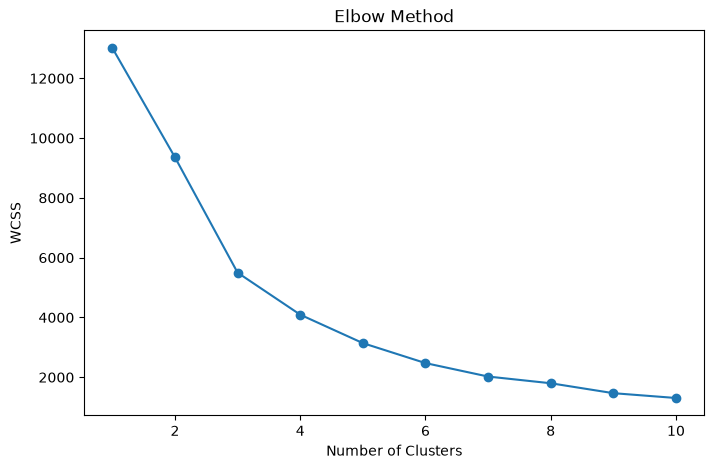

In [21]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [22]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [23]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


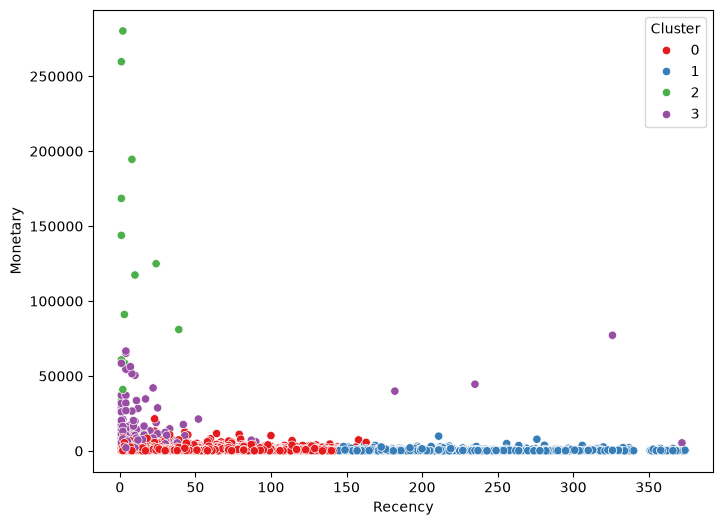

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.show()

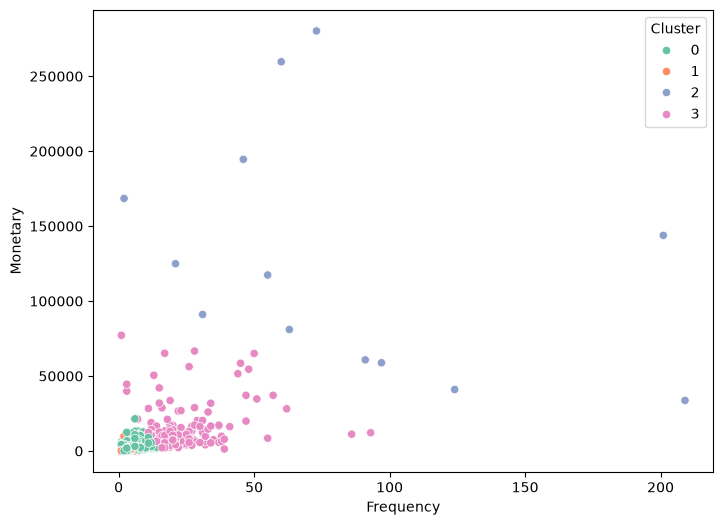

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.show()

In [26]:
rfm['Cluster'].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

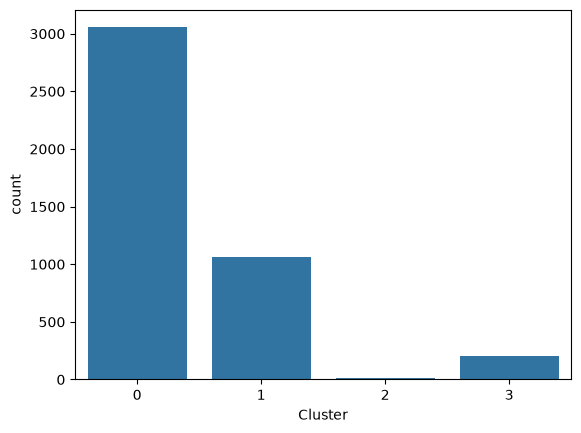

In [27]:
sns.countplot(x='Cluster', data=rfm)

plt.show()

In [28]:
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


## Cluster Interpretation

| Cluster | Interpretation | Marketing Strategy |
|---------|----------------|--------------------|
| **0** | Regular Customers (Recent purchases, moderate frequency, moderate spending) | Offer loyalty points, personalized product recommendations, and seasonal discounts. |
| **1** | At-Risk Customers (Long time since last purchase, low frequency, low spending) | Send win-back emails, discount coupons, and special offers to encourage them to return. |
| **2** | VIP / High-Value Customers (Very recent purchases, highest purchase frequency, highest spending) | Provide VIP membership, exclusive offers, early access to products, and premium customer support. |
| **3** | Loyal Customers (Recent purchases, good purchase frequency, high spending) | Reward with loyalty programs, cross-sell premium products, and offer referral incentives. |

Conclusion

Customer Segmentation Analysis using K-Means

The customer data was analyzed using the RFM (Recency, Frequency, Monetary) model. After cleaning and standardizing the data, the K-Means clustering algorithm was applied. The Elbow Method was used to determine the optimal number of clusters. Four customer segments were identified based on their purchasing behavior. These segments help businesses understand different customer groups and create targeted marketing strategies, improving customer satisfaction, retention, and overall sales.